In [4]:
import os
import json
from matplotlib import pyplot as plt
import numpy as np

info_fn = "/mnt/sdc/data/err_empty_syn/check_empty_depth_v0.1.0.json"
with open(info_fn, "r") as fp:
    info = json.load(fp)
print(f"Loaded {len(info)} frames")
print(info[0])

Loaded 367424 frames
{'empty_depth: median': 3.996, 'empty_depth: mean': 4.0208147357374795, 'depth: median': 4.5515, 'depth: mean': 4.583669355051612, 'empty_depth/depth: median': 0.876329043088976, 'empty_depth/depth: mean': 0.8775067859686101, 'empty_depth/depth: diff10': 0.9986799955368042, 'empty_depth/depth: diff20': 2.639985177665949e-05, 'empty_depth/depth: diff50': 0.0, 'empty_depth/depth: diff100': 0.0, 'empty_depth/depth: diff200': 0.0, 'empty_depth - depth: median': -0.5575000000000001, 'empty_depth - depth: mean': -0.5628546193141318}


In [10]:
depth_median = np.array([c["depth: median"] for c in info if c is not None])
depth_mean = np.array([c["depth: mean"] for c in info if c is not None])
div_median = np.array([c["empty_depth/depth: median"] for c in info if c is not None])
div_mean = np.array([c["empty_depth/depth: mean"] for c in info if c is not None])
print(f"{len(depth_median)} valid frames")

367423 valid frames


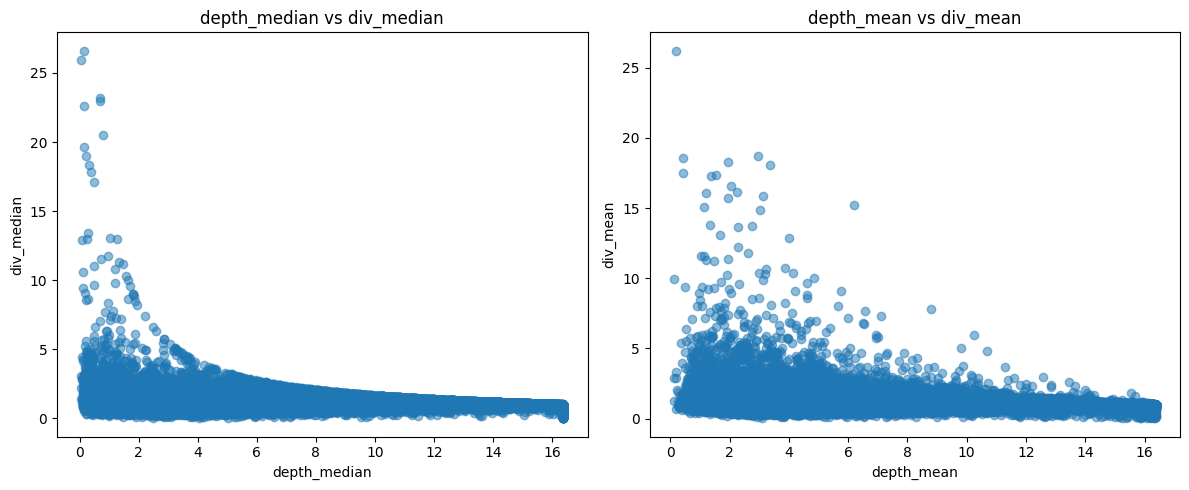

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(depth_median, div_median, alpha=0.5)
axes[0].set_xlabel('depth_median')
axes[0].set_ylabel('div_median')
axes[0].set_title('depth_median vs div_median')

axes[1].scatter(depth_mean, div_mean, alpha=0.5)
axes[1].set_xlabel('depth_mean')
axes[1].set_ylabel('div_mean')
axes[1].set_title('depth_mean vs div_mean')

plt.tight_layout()
plt.show()

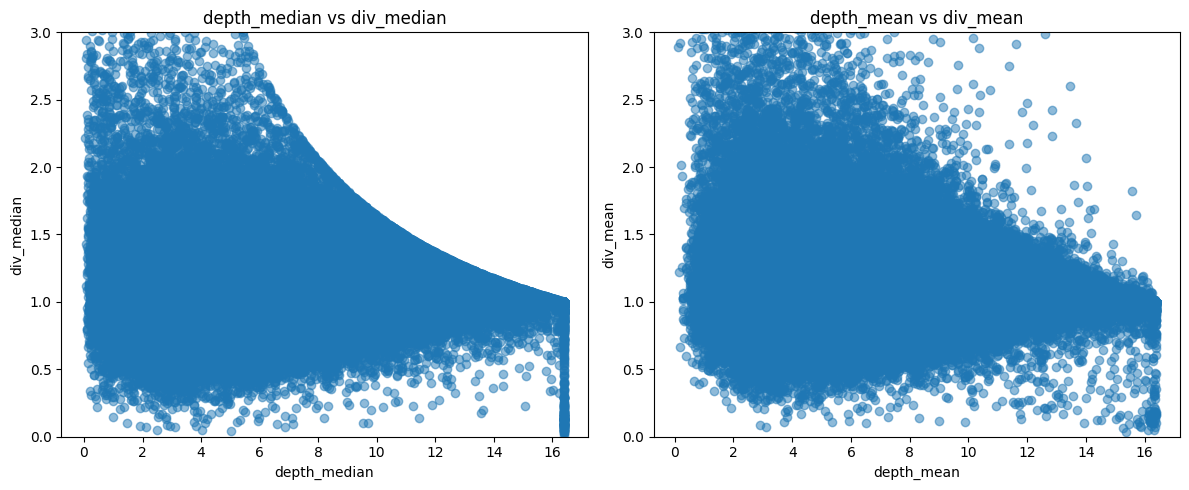

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].set_ylim(0, 3.0)
axes[1].set_ylim(0, 3.0)

axes[0].scatter(depth_median, div_median, alpha=0.5)
axes[0].set_xlabel('depth_median')
axes[0].set_ylabel('div_median')
axes[0].set_title('depth_median vs div_median')

axes[1].scatter(depth_mean, div_mean, alpha=0.5)
axes[1].set_xlabel('depth_mean')
axes[1].set_ylabel('div_mean')
axes[1].set_title('depth_mean vs div_mean')

plt.tight_layout()
plt.show()

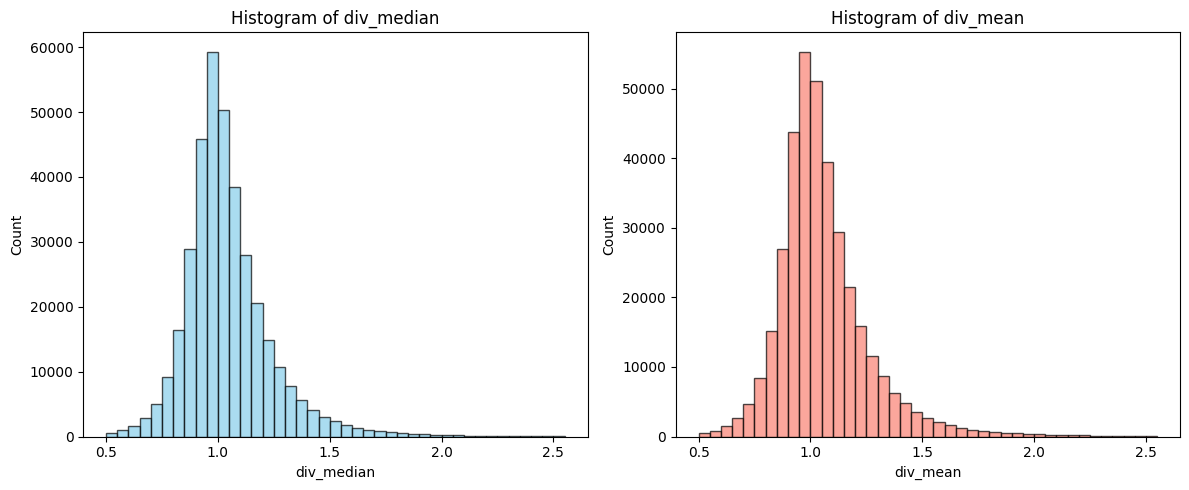

In [14]:
bins = np.arange(0.5, 2.6, 0.05)
bins = np.insert(bins, 0, -np.inf)  # leftmost bin: <0.5
bins = np.append(bins, np.inf)      # rightmost bin: >2.5

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(div_median, bins=bins, alpha=0.7, color='skyblue', edgecolor='black')
axes[0].set_title('Histogram of div_median')
axes[0].set_xlabel('div_median')
axes[0].set_ylabel('Count')

axes[1].hist(div_mean, bins=bins, alpha=0.7, color='salmon', edgecolor='black')
axes[1].set_title('Histogram of div_mean')
axes[1].set_xlabel('div_mean')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [19]:
low_thresh, high_thresh = 0.9, 1.05
select_idxs = (div_median > low_thresh) & (div_median < high_thresh)
select_idxs &= (div_mean > low_thresh) & (div_mean < high_thresh)
print(f"select in ({low_thresh}, {high_thresh}): {select_idxs.sum()} frames")

select in (0.9, 1.05): 140590 frames
